# SPECTRE field integrity: from a boundary to the island metric

VMEC assumes nested flux surfaces, so the equilibrium it returns cannot show the magnetic islands its own boundary hosts. [SPECTRE](https://gitlab.com/spectre-eq/spectre) solves the same boundary without that assumption. This notebook goes from a plasma boundary, the object a ConStellaration submission consists of, to its `FieldIntegrityMetrics`: the share of the toroidal flux held by island chains.

The design is one from the dataset (`misc.vmecpp_wout_id = DcPhJsLe4Zv8aphYRMNhuRw`, three field periods). Its rotational transform crosses two low-order rationals, and the higher-order chain turns out to be the larger one.

Everything runs on a laptop, on one core: the SPECTRE solve takes one to two minutes and about 3.5 GB of memory, the search of the two island chains one to two minutes more. SPECTRE has to be installed, which `pip install` of this repository does from source (it needs a Fortran compiler, CMake, MPI, HDF5 and OpenBLAS).

In [1]:
%load_ext autoreload
%autoreload 2

import pathlib

import numpy as np

from constellaration import forward_model
from constellaration.geometry import surface_rz_fourier
from constellaration.mhd import spectre, spectre_settings, vmec_utils
from constellaration.utils import visualization

The expensive steps write their result next to the notebook and load it on the next run. Set a flag to `True` to compute that step again.

In [2]:
CACHE_DIR = pathlib.Path.cwd().resolve() / "spectre_field_integrity_cache"
CACHE_DIR.mkdir(exist_ok=True)
EQUILIBRIUM_FILE = CACHE_DIR / "equilibrium.json"
SPECTRE_OUTPUT_FILE = CACHE_DIR / "spectre_output.json"
METRICS_FILE = CACHE_DIR / "field_integrity_metrics.json"

RUN_VMEC = False  # False: download the equilibrium the dataset publishes
RUN_SPECTRE = False
RUN_CHAIN_SEARCH = False

## The boundary

A boundary is a set of Fourier coefficients of R and Z. This one is copied from the dataset row of the design.

In [3]:
boundary = surface_rz_fourier.SurfaceRZFourier.model_validate_json(
    '{"r_cos":[[0.0,0.0,0.0,0.0,1.0,0.0,-0.02702702702702703,0.0,0.0],[0.0,0.0,0.08978104821425961,-0.019465376230152362,0.17956209642851922,-0.019465376230152362,0.0,0.0,0.0],[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]],"z_sin":[[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.0,0.0,0.08978104821425961,0.0064884587433841215,-0.17956209642851922,0.0064884587433841215,0.0,0.0,0.0],[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]],"r_sin":null,"z_cos":null,"n_field_periods":3,"n_periodicity":1,"is_stellarator_symmetric":true}'
)
visualization.plot_surface(boundary)

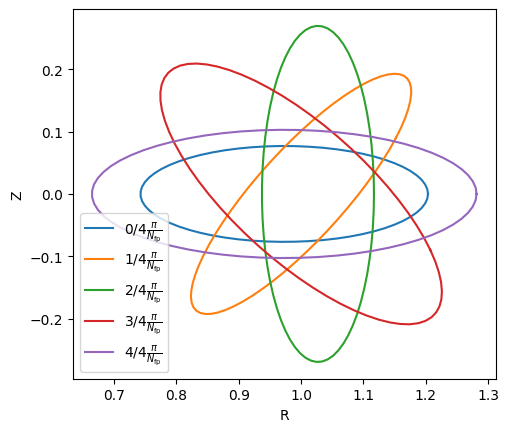

In [4]:
_ = visualization.plot_boundary(boundary)

## The VMEC equilibrium

The dataset publishes the VMEC++ equilibrium of every design, so it is downloaded rather than solved again. With `RUN_VMEC = True` the forward model solves it here instead, at the fidelity the dataset was made with; that takes about ten minutes and gives the same rotational transform to nine digits.

In [5]:
WOUT_ID = "DcPhJsLe4Zv8aphYRMNhuRw"

if EQUILIBRIUM_FILE.exists() and not RUN_VMEC:
    equilibrium = vmec_utils.VmecppWOut.model_validate_json(
        EQUILIBRIUM_FILE.read_text()
    )
elif RUN_VMEC:
    settings = forward_model.ConstellarationSettings.default_high_fidelity_skip_qi()
    _, equilibrium = forward_model.forward_model(boundary, settings=settings)
    EQUILIBRIUM_FILE.write_text(equilibrium.model_dump_json())
else:
    import huggingface_hub
    import pyarrow.parquet as pq

    def download(filename):
        return huggingface_hub.hf_hub_download(
            "proxima-fusion/constellaration", filename, repo_type="dataset"
        )

    # One file of a few hundred MB holds the equilibrium, among a hundred others.
    file_of_id = pq.read_table(
        download("vmecpp_wout/id_to_file_map.parquet"), filters=[("id", "=", WOUT_ID)]
    )
    shard = pathlib.Path(file_of_id.column("path")[0].as_py()).name
    row = pq.read_table(
        download(f"vmecpp_wout/{shard}"), filters=[("id", "=", WOUT_ID)]
    )
    # The published JSON is cached as it is: an equilibrium of the dataset does not
    # survive being written out again by ``model_dump_json``.
    EQUILIBRIUM_FILE.write_text(row.column("json")[0].as_py())
    equilibrium = vmec_utils.VmecppWOut.model_validate_json(
        EQUILIBRIUM_FILE.read_text()
    )

VMEC's flux surfaces on the plane half a field period from the first one. They are nested by construction.

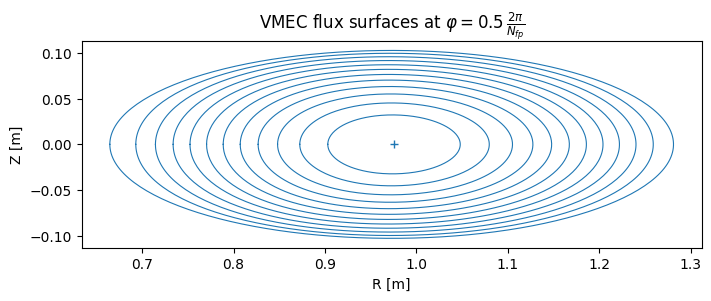

In [6]:
_ = visualization.plot_flux_surfaces_cross_section(
    equilibrium, normalized_toroidal_angle=0.5, figsize=(8, 3.5)
)

## The rotational transform and the rationals it crosses

An island chain can open where the rotational transform equals a rational n/m, with n a multiple of the number of field periods. The screen lists every such crossing with m up to `max_poloidal_order` (20 by default), lowest order first, and keeps the `max_rationals` lowest-order rationals. The order m is not a measure of the island's size; it is an entry screen, on the premise that a chain of order above 20 cannot hold a significant share of the flux.

`max_rationals` is 3 by default. Here it is set to 2: the third rational of this design, 6/7, is crossed right next to the magnetic axis, where the search does not find its chain and spends a quarter of an hour establishing that.

Rationals crossed with m <= 20:
  3/3, 6/5, 6/7, 9/7, 9/8, 12/9, 9/10, 12/11, 15/11, 15/12, 12/13, 15/13, 18/13, 15/14, 21/15, 15/16, 21/16, 15/17, 18/17, 21/17, 24/17, 21/18, 18/19, 21/19, 24/19, 27/19, 21/20, 27/20


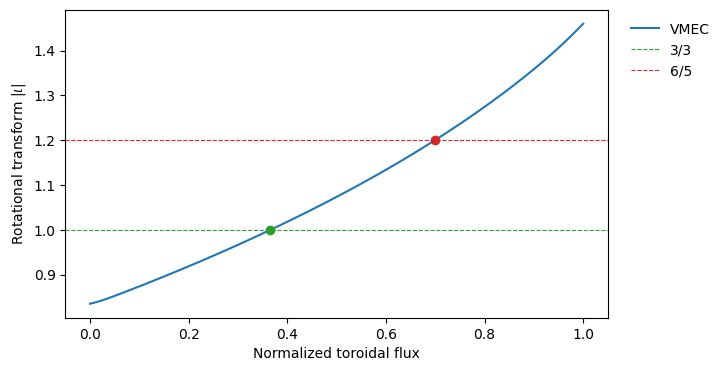

In [7]:
solver_settings = spectre_settings.SpectreSettings(max_rationals=2)

iota = np.asarray(equilibrium.iotaf)
s_coordinate = equilibrium.normalized_toroidal_flux_full_grid_mesh
crossed = spectre._find_crossings(
    iota,
    s_coordinate,
    equilibrium.n_field_periods,
    solver_settings.max_poloidal_order,
)
print(f"Rationals crossed with m <= {solver_settings.max_poloidal_order}:")
print("  " + ", ".join(f"{r.n}/{r.m}" for r in crossed))

refusal, crossings = spectre.screen_rotational_transform(
    iota, s_coordinate, equilibrium.n_field_periods, solver_settings
)
_ = visualization.plot_rotational_transform(equilibrium, crossings, figsize=(7, 4))

Each selected crossing carries what the metric needs from VMEC: where it is, and the shear of the unperturbed profile there.

In [8]:
for r in crossings:
    print(
        f"iota = {r.n}/{r.m}: m = {r.m}, n = {r.n},"
        f" N_fp = {equilibrium.n_field_periods},"
        f" crossed at psi_n = {r.psi_n:.3f}, shear |d iota / d psi_n| = {r.shear:.3f}"
    )

iota = 3/3: m = 3, n = 3, N_fp = 3, crossed at psi_n = 0.366, shear |d iota / d psi_n| = 0.519
iota = 6/5: m = 5, n = 6, N_fp = 3, crossed at psi_n = 0.699, shear |d iota / d psi_n| = 0.699


## From VMEC to SPECTRE

SPECTRE's own converter turns the VMEC equilibrium into a SPECTRE input: one volume filled with a vacuum field, bounded by the same surface. `spectre_input` adds the one thing the converter leaves out, the magnetic axis, which is set to VMEC's and pinned there. The poloidal resolution follows the highest order selected, `mpol = max(14, 1.5 m)`.

In [9]:
highest_order = max(r.m for r in crossings)
mpol = solver_settings.poloidal_modes(highest_order)
ntor = solver_settings.toroidal_ladder[0]
parameters = spectre._build_spectre_input_parameters(
    equilibrium, solver_settings, mpol, ntor, radial_resolution=mpol + 4
)
physics = parameters.physics
print(
    f"nvol = {physics.nvol}, mpol = {physics.mpol}, ntor = {physics.ntor},"
    f" lrad = {physics.lrad[0]}"
)
print(f"axis R harmonics: {np.round(physics.rac[:4], 5)}")
print(f"axis Z harmonics: {np.round(physics.zas[:4], 5)}")
print(f"axis pinned: {parameters.numeric.lrzaxis == 0}")

nvol = 1, mpol = 14, ntor = 14, lrad = 18
axis R harmonics: [ 9.974e-01 -7.100e-04 -2.399e-02 -1.700e-04]
axis Z harmonics: [-0.       0.00112  0.00337 -0.00022]
axis pinned: True


## The SPECTRE solve

`run_spectre` screens the transform, builds that input and solves the field, climbing the toroidal resolutions 14, 18, 22, 26 until the Beltrami residual (how well the field satisfies its equation) is below the tolerance. It returns a `SpectreOutput` holding SPECTRE's complete HDF5 file, so the metrics can be recomputed later without solving again.

The solve runs in a child process of the notebook kernel, on one core.

In [10]:
if SPECTRE_OUTPUT_FILE.exists() and not RUN_SPECTRE:
    spectre_output = spectre.SpectreOutput.model_validate_json(
        SPECTRE_OUTPUT_FILE.read_text()
    )
else:
    spectre_output = spectre.run_spectre(equilibrium, solver_settings)
    SPECTRE_OUTPUT_FILE.write_text(spectre_output.model_dump_json())

print(f"refusal class: {spectre_output.refusal_class.value}")
print(f"Beltrami residual of each rung solved: {spectre_output.beltrami_residuals}")
print(f"HDF5 file: {len(spectre_output.h5_file) / 1e6:.1f} MB")

refusal class: NONE
Beltrami residual of each rung solved: [0.0002445191745019933]
HDF5 file: 11.9 MB


## The field integrity metrics

`compute_field_integrity_metrics` searches, in the solved field, one O-point and one X-point of the chain at each selected crossing, and reads their Greene residues $R_O$ and $R_X$ from SPECTRE's tangent map. Each chain is scored

$$M = \frac{4}{\pi}\,N_{fp}\,\frac{|R_O R_X|^{1/4}}{m^2\,|d\iota/d\psi_n|}$$

which is the full width of its islands as a fraction of the toroidal flux. The field integrity score of the design is the sum over its chains: between 0 and 1, 0 meaning no island and 1 islands from the axis to the boundary. The two chains are searched in two processes.

In [11]:
if METRICS_FILE.exists() and not RUN_CHAIN_SEARCH:
    metrics = spectre.FieldIntegrityMetrics.model_validate_json(
        METRICS_FILE.read_text()
    )
else:
    metrics = spectre.compute_field_integrity_metrics(spectre_output, equilibrium)
    METRICS_FILE.write_text(metrics.model_dump_json())

for chain in metrics.chains:
    print(
        f"{chain.n}/{chain.m}: R_O = {chain.residue_o:+.3e},"
        f" R_X = {chain.residue_x:+.3e},"
        f" |R_X/R_O| = {chain.residue_ratio:.3f}, M = {chain.score:.4f}"
    )
print()
print(f"field integrity score M = {metrics.field_integrity_score:.4f}")
print(f"chains found: {len(metrics.chains)} of {len(metrics.crossings)}")
print(f"Beltrami residual: {metrics.beltrami_residual:.2e}")
print(f"refusal class: {metrics.refusal_class.value}")
print(
    "predicted destroyed flux, Delta Phi / Phi_edge ="
    f" {spectre.predicted_flux_fraction(metrics.field_integrity_score):.3f}"
)

3/3: R_O = +1.725e-03, R_X = -1.803e-03, |R_X/R_O| = 1.045, M = 0.0343
6/5: R_O = +5.085e-02, R_X = -5.244e-02, |R_X/R_O| = 1.031, M = 0.0497

field integrity score M = 0.0840
chains found: 2 of 2
Beltrami residual: 2.45e-04
refusal class: NONE
predicted destroyed flux, Delta Phi / Phi_edge = 0.054


The 6/5 chain is the larger of the two although 3/3 is the lower-order rational: scoring the lowest order alone would have reported less than half of this design's field integrity score.

## What VMEC could not show

The upper half of the figure is VMEC: nested surfaces, by assumption. The lower half is the same plane of the SPECTRE field, with field lines followed for 300 field periods. The section is up-down symmetric on this plane, so nothing is hidden by showing half of each. The O-points and X-points are those of the two chains scored above.

Three helpers for the figures below. They only read the solved field (SPECTRE's own `SPECTREout`, from `spectre.load_field`); the metrics do not use them.

In [12]:
def poincare_section(
    field, normalized_toroidal_angle=0.0, n_field_lines=60, n_punctures=300
):
    """Punctures of field lines of the solved field with one toroidal plane.

    Field lines are seeded evenly in the radial coordinate from the axis to the
    boundary and followed for ``n_punctures`` field periods. Returns one ``(n, 2)``
    array of (R, Z) per field line.
    """
    lines = []
    for s in np.linspace(-0.97, 0.99, n_field_lines):
        _, rz, _, _ = field.trace_one_fieldline(
            [float(s), 0.0],
            0,
            num_phi_planes=1,
            num_transits=n_punctures,
            zetan_start=normalized_toroidal_angle,
            rtol=1e-9,
            atol=1e-9,
        )
        points = np.asarray(rz, dtype=float).reshape(2, -1).T
        lines.append(points[np.isfinite(points).all(axis=1)])
    return lines


def chain_points(field, chain, on_half_period_plane=False):
    """Every O-point and X-point of a chain, as two ``(m, 2)`` arrays of (R, Z).

    The chain's record holds one point of each kind on the plane zeta = 0; following
    it for m field periods visits the other m - 1. ``on_half_period_plane`` returns
    the points on the plane half a field period on, the other stellarator-symmetric
    plane.
    """
    points = []
    for s, theta in (chain.o_point, chain.x_point):
        _, rz, _, _ = field.trace_one_fieldline(
            [s, theta],
            0,
            num_phi_planes=2,
            num_transits=chain.m,
            method="DOP853",
            rtol=1e-10,
            atol=1e-10,
        )
        rz = np.asarray(rz, dtype=float).reshape(2, -1).T
        points.append(rz[1 if on_half_period_plane else 0 :: 2][: chain.m])
    return points[0], points[1]


def rotational_transform_profile(field, equilibrium, n_field_lines=40, n_transits=200):
    """|iota| of the solved field against normalised toroidal flux, by field lines.

    Each field line starts on the outboard midplane of the plane zeta = 0 and is
    labelled by the VMEC flux surface that passes through its starting point, so the
    profile shares its radial label with VMEC's. Inside an island the transform is
    flat at the island's rational.
    """
    # On the outboard midplane of zeta = 0 every harmonic of R adds up.
    psi_n = equilibrium.normalized_toroidal_flux_full_grid_mesh
    r_outboard = np.sum(np.asarray(equilibrium.rmnc), axis=0)
    order = np.argsort(r_outboard)
    labels, transform = [], []
    for s in np.linspace(-0.95, 0.99, n_field_lines):
        _, _, traced, ok = field.trace_one_fieldline(
            [float(s), 0.0], 0, num_phi_planes=1, num_transits=n_transits
        )
        value = abs(float(traced))
        # A failed trace is written as iota = +-2 while it still reports success.
        if ok and np.isfinite(value) and not np.isclose(value, 2.0):
            r_start, _ = field.get_rz_coords(0, float(s), 0.0, 0.0)
            labels.append(
                float(np.interp(float(r_start), r_outboard[order], psi_n[order]))
            )
            transform.append(value)
    return np.array(labels), np.array(transform)

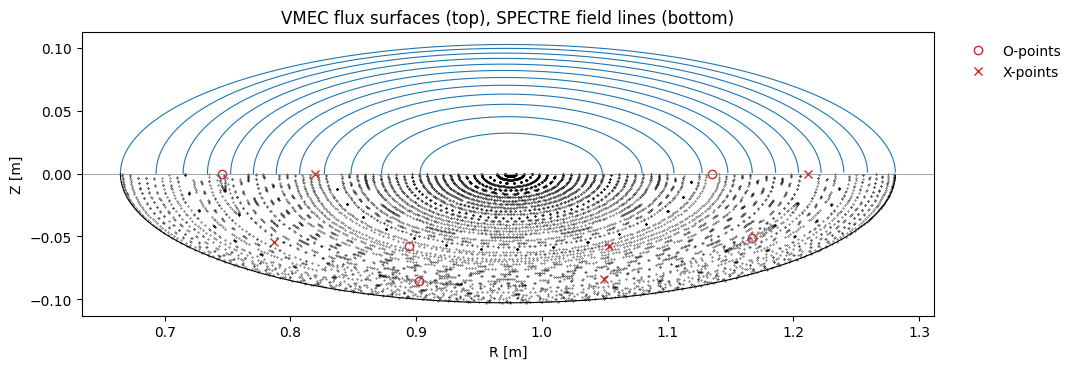

In [13]:
field = spectre.load_field(spectre_output)
field_lines = poincare_section(
    field, normalized_toroidal_angle=0.5, n_field_lines=50, n_punctures=300
)
points_of_chains = [
    chain_points(field, chain, on_half_period_plane=True) for chain in metrics.chains
]
_ = visualization.plot_poincare_section(
    equilibrium,
    field_lines,
    points_of_chains,
    normalized_toroidal_angle=0.5,
    figsize=(11, 4.5),
)

The rotational transform of the SPECTRE field, measured along field lines, follows VMEC's except inside the islands, where it is flat at the island's rational.

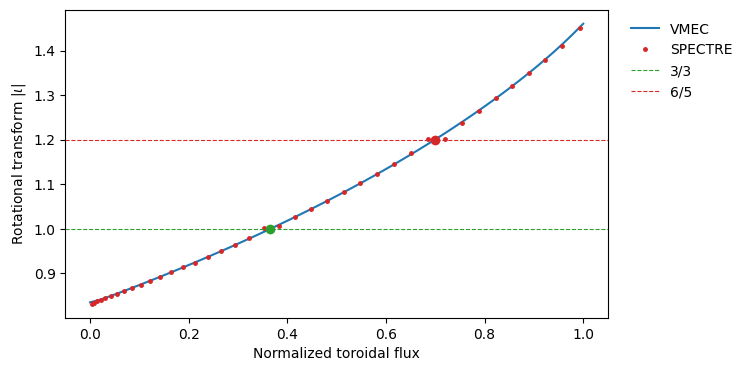

In [14]:
spectre_profile = rotational_transform_profile(field, equilibrium)
_ = visualization.plot_rotational_transform(
    equilibrium, metrics.crossings, spectre_profile, figsize=(7, 4)
)

## In one call

The forward model runs both steps when it is given SPECTRE settings, and returns the metrics with the others. It solves VMEC and SPECTRE again, so this cell is not run by default.

In [15]:
RUN_FORWARD_MODEL = False

if RUN_FORWARD_MODEL:
    settings = forward_model.ConstellarationSettings.default_high_fidelity_skip_qi()
    settings.spectre_settings = solver_settings
    all_metrics, _ = forward_model.forward_model(boundary, settings=settings)
    print(all_metrics.field_integrity.model_dump_json(indent=2, exclude={"crossings"}))